# Function 7 — Bayesian Optimization Campaign

This notebook documents the search for the input `(x1, ..., x6)` that **maximizes** an
unknown ("black-box") 6D function. A Gaussian Process (GP) surrogate model is fit to the
observed data, and acquisition functions (Expected Improvement, Upper Confidence Bound) are
used to decide which point to query next.

## 1. Setup

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import minimize
from scipy.stats import norm, qmc
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import Matern, WhiteKernel, ConstantKernel as C
import torch
import torch.nn as nn
import torch.optim as optim

## 2. Initial Data

In [2]:
X = np.load("function_7/data/initial_inputs.npy")
y = np.load("function_7/data/initial_outputs.npy")

Additional query rounds, appended as results came in:

In [3]:
X = np.append(X, [
    [0.029000, 0.491900, 0.247000, 0.218000, 0.420800, 0.731000],
    [0.000050, 0.411098, 0.228833, 0.144114, 0.346375, 0.736693],
    [0.000001, 0.193675, 0.623099, 0.079174, 0.348890, 0.858315],
    [0.009000, 0.506755, 0.009000, 0.009000, 0.346587, 0.841719],
    [0.000001, 0.237979, 0.404631, 0.121878, 0.334399, 0.759561],
    [0.076968, 0.579575, 0.866761, 0.221407, 0.017187, 0.862321],
    [0.081330, 0.682424, 0.427299, 0.178955, 0.628009, 0.327001],
    [0.397481, 0.481957, 0.995121, 0.070858, 0.210922, 0.894747],
    [0.000099, 0.999999, 0.999999, 0.000099, 0.000099, 0.000099],
    [0.000099, 0.000099, 0.999900, 0.000099, 0.000099, 0.573262],
    [0.000001, 0.000001, 0.451211, 0.000001, 0.150686, 0.999999],
    [0.000010, 0.324538, 0.316732, 0.132996, 0.340387, 0.748127],
    [0.000005, 0.254538, 0.366732, 0.125996, 0.337387, 0.759027],
    ], axis=0)

y = np.append(y, [
    1.3159104245362119,
    1.5250340981229598,
    1.484140720411121,
    0.4635446910534653,
    1.9993628649406798,
    0.8214784402068228,
    0.24858502604330204,
    0.8852200593800396,
    0.006742683345401777,
    0.11554102170838587,
    0.36905511970312405,
    1.804396780440382,
    1.9445079828358085,
    ], axis=0)

print(f"X shape: {X.shape}, y shape: {y.shape}")
print(f"Best observed y so far: {max(y)}")

X shape: (43, 6), y shape: (43,)
Best observed y so far: 1.9993628649406798


## 3. Gaussian Process Surrogate Model

A `Matern(nu=2.5)` kernel is combined with a `WhiteKernel` to explicitly model noise in the
training data.

In [4]:
kernel = C(1.0) * Matern(length_scale=[0.5] * 6, length_scale_bounds=(0.01, 10.0), nu=2.5) + WhiteKernel(noise_level=1)
gp_model = GaussianProcessRegressor(kernel=kernel, n_restarts_optimizer=25)
gp_model.fit(X, y)

print("Length Scales:", gp_model.kernel_.get_params()['k1__k2__length_scale'])

Length Scales: [ 0.95560238 10.          0.44613071  0.53123806  0.26160574  0.19656673]


/Users/theshiekh/Library/Caches/pypoetry/virtualenvs/emeritus-emhPt3nG-py3.12/lib/python3.12/site-packages/sklearn/gaussian_process/kernels.py:455: ConvergenceWarning: The optimal value found for dimension 1 of parameter k1__k2__length_scale is close to the specified upper bound 10.0. Increasing the bound and calling fit again may find a better value.
  warnings.warn(


## 4. Acquisition Functions

### Expected Improvement (EI)
`xi` is the exploration parameter. Rather than a single starting point, a Sobol
quasi-random sequence (`scipy.stats.qmc`) is used to generate well-spread starting points
across the 6D space, and the best local optimum found across all of them is kept.

In [5]:
def expected_improvement(x_test, gp, y_max, xi=0.1):
    x_test = np.atleast_2d(x_test)
    mu, sigma = gp.predict(x_test, return_std=True)
    sigma = np.maximum(sigma, 1e-9)  # avoid division by zero

    imp = mu - y_max - xi
    Z = imp / sigma
    ei = imp * norm.cdf(Z) + sigma * norm.pdf(Z)

    return -ei.flatten()  # negative for minimization

d = 6
n_starts = 32  # power of 2, for Sobol efficiency
sampler = qmc.Sobol(d=d, scramble=True)
initial_guesses = sampler.random(n=n_starts)

best_ei_found = np.inf
best_next_point = None
current_best_y = np.max(y)

for x0 in initial_guesses:
    res = minimize(
        expected_improvement,
        x0,
        args=(gp_model, current_best_y),
        bounds=[(0, 1)] * d,
        method='L-BFGS-B'
    )

    if res.fun < best_ei_found:
        best_ei_found = res.fun
        best_next_point = res.x

print(f"Suggested Next Iteration Point (EI): {best_next_point}")

Suggested Next Iteration Point (EI): [0.0071385  0.         0.49640516 0.05540174 0.32736602 0.73343681]


Third iteration: continuing to exploit the current best region, with moderate exploration.

### Upper Confidence Bound (UCB)
`kappa` controls the exploration/exploitation trade-off.

In [6]:
def ucb_loss(x_test, kappa=10):
    mu, sigma = gp_model.predict(x_test.reshape(1, -1), return_std=True)
    ucb = mu + kappa * sigma
    return -ucb

x_init = X[np.argmax(y)]  # start from current best
res = minimize(ucb_loss, x_init, bounds=[(0, 1)] * 6, method='L-BFGS-B')

print(f"Current Best Y: {np.max(y)}")
print(f"Next Suggested Point (UCB): {res.x}")

next_point = best_next_point  # EI candidate is used as the final suggestion

Current Best Y: 1.9993628649406798
Next Suggested Point (UCB): [0.         0.         0.72295677 0.         0.4032842  0.62530897]


### Ranked Observations
A quick sanity check on where the current samples rank by yield.

In [7]:
sorted_indices = np.argsort(y)
sorted_values = y[sorted_indices]

print(f"{'Rank':<6} | {'Orig Index':<10} | {'Value':<10}")
print("-" * 32)
for rank, idx in enumerate(sorted_indices):
    print(f"{rank:<6} | {idx:<10} | {sorted_values[rank]:.2f}")

Rank   | Orig Index | Value     
--------------------------------
0      | 19         | 0.00
1      | 27         | 0.00
2      | 26         | 0.00
3      | 38         | 0.01
4      | 21         | 0.01
5      | 2          | 0.01
6      | 12         | 0.01
7      | 15         | 0.01
8      | 8          | 0.02
9      | 20         | 0.02
10     | 28         | 0.02
11     | 9          | 0.03
12     | 18         | 0.04
13     | 3          | 0.06
14     | 17         | 0.07
15     | 10         | 0.07
16     | 5          | 0.08
17     | 7          | 0.09
18     | 29         | 0.10
19     | 22         | 0.10
20     | 39         | 0.12
21     | 11         | 0.21
22     | 36         | 0.25
23     | 13         | 0.27
24     | 4          | 0.27
25     | 16         | 0.27
26     | 40         | 0.37
27     | 33         | 0.46
28     | 23         | 0.48
29     | 25         | 0.52
30     | 1          | 0.56
31     | 0          | 0.60
32     | 14         | 0.61
33     | 24         | 0.68
34     | 35     

## 5. Supplementary Analysis — Neural Network Saliency

Existing samples are manually labeled "positive" (high-yield, indices `[31, 32, 6, 30, 24]`)
or "negative", and a small neural network is trained on that split as a sanity check on
whether the acquisition function's suggested `next_point` also looks promising from a
classification standpoint. This is exploratory and not part of the core GP/acquisition-function
decision loop.

In [8]:
y_labels = np.zeros(len(X))
positive_indices = [31, 32, 6, 30, 24]
y_labels[positive_indices] = 1

X_tensor = torch.tensor(X, dtype=torch.float32, requires_grad=True)
y_tensor = torch.tensor(y_labels, dtype=torch.float32).reshape(-1, 1)

nn_model_deep = nn.Sequential(
    nn.Linear(6, 36),
    nn.ReLU(),
    nn.Linear(36, 1),
    nn.Sigmoid()
)

optimizer = optim.Adam(nn_model_deep.parameters(), lr=0.01)
criterion = nn.BCELoss()

for _ in range(2000):
    optimizer.zero_grad()
    outputs = nn_model_deep(X_tensor)
    loss = criterion(outputs, y_tensor)
    loss.backward()
    optimizer.step()

X_tensor.grad.zero_()
output = nn_model_deep(X_tensor)
output.backward(torch.ones_like(output))

deep_importance = X_tensor.grad.abs().sum(dim=1).detach().numpy()

print("Point | Deep Importance Score")
for i, score in enumerate(deep_importance):
    print(f"{i:2d}    | {score:.4f}")

Point | Deep Importance Score
 0    | 0.0013
 1    | 0.0000
 2    | 0.0010
 3    | 0.0000
 4    | 0.0000
 5    | 0.0000
 6    | 0.0597
 7    | 0.0000
 8    | 0.0096
 9    | 0.0000
10    | 0.1417
11    | 0.0000
12    | 0.0000
13    | 0.0112
14    | 0.0000
15    | 0.0000
16    | 0.0000
17    | 0.0000
18    | 0.0328
19    | 0.0000
20    | 0.0012
21    | 0.0239
22    | 0.0000
23    | 0.1442
24    | 0.3654
25    | 0.0000
26    | 0.0001
27    | 0.0000
28    | 0.0000
29    | 0.0000
30    | 0.0458
31    | 15.8061
32    | 5.4079
33    | 0.8033
34    | 0.1220
35    | 0.0001
36    | 0.0000
37    | 0.2661
38    | 0.0000
39    | 0.0000
40    | 0.0000
41    | 20.2093
42    | 0.1226


In [9]:
nn_model_deep.eval()
sample_input = torch.tensor(np.array([next_point]), dtype=torch.float32)

with torch.no_grad():
    prediction_prob = nn_model_deep(sample_input)

print(f"Next point: {next_point}")
print(f"Probability of being Positive (Class 1): {prediction_prob.item():.4f}")
predicted_label = 1 if prediction_prob.item() >= 0.5 else 0
print(f"Predicted Class: {predicted_label}")

Next point: [0.0071385  0.         0.49640516 0.05540174 0.32736602 0.73343681]
Probability of being Positive (Class 1): 0.0000
Predicted Class: 0


## 6. Results Summary

Observed yield over the most recent iterations:

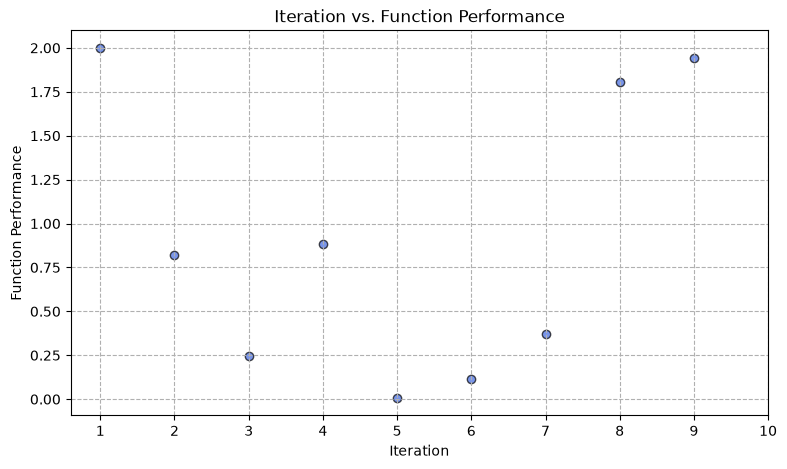

In [10]:
plt.figure(figsize=(9, 5))
plt.scatter(
    list(range(1, 10)), y[-9:], color="royalblue", alpha=0.7, edgecolors="k"
)
plt.xticks(list(range(1, 11)))
plt.title("Iteration vs. Function Performance")
plt.xlabel("Iteration")
plt.ylabel("Function Performance")
plt.grid(True, linestyle="--", alpha=1)
plt.savefig("function_7/function_7_chart_9th_iteration.png")
plt.show()